In [1]:
import numpy as np
import os
DATASET_PATH = "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"

patient = "sub-strokecase0001"
patient_path = os.path.join(DATASET_PATH, patient)

for file in ["flair.npy", "adc.npy", "dwi.npy", "mask.npy"]:
    data = np.load(os.path.join(patient_path, file))
    print(f"{file}")
    print(f"Shape : {data.shape}")
    print(f"Dtype : {data.dtype}")
    print("-" * 40)

flair.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
adc.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
dwi.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
mask.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------


### Import Libraries

In [2]:
# Installation des bibliothèques nécessaires (MONAI, Nibabel, SimpleITK)
!pip install -q monai nibabel SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.1 MB/s eta 0:00:0000:010:01


In [3]:
# installation mlflow
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 85.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 81.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 13.4 MB/s eta 0:00:00


In [4]:
# Standard Libraries

import os
import random
from pathlib import Path
import mlflow

import numpy as np
import matplotlib.pyplot as plt

# PyTorch

import torch
from torch.utils.data import Dataset, DataLoader

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# Data Split

from sklearn.model_selection import train_test_split


# MONAI

from monai.networks.nets import UNet

from monai.losses import DiceCELoss

from monai.metrics import (
    DiceMetric,
    MeanIoU
)

from monai.transforms import (
    Compose,
    Activations,
    AsDiscrete
)

from monai.data import decollate_batch
from torch.optim import Adam
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU

from pathlib import Path
import random
import numpy as np
import torch

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print(f"PyTorch Version : {torch.__version__}")
print(f"MONAI Version   : {__import__('monai').__version__}")
print(f"Device          : {device}")
print("=" * 50)

PyTorch Version : 2.10.0+cu128
MONAI Version   : 1.6.0
Device          : cuda


### configuration de model

In [6]:
# configuration mlflow server
MLFLOW_TRACKING_URI = "https://elated-autistic-subfloor.ngrok-free.dev"  
EXPERIMENT_NAME = "Stroke-Segmentation"

In [7]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    client = mlflow.MlflowClient()
    client.search_experiments()  # ping simple pour tester la connexion
    print(f"Connexion réussie au serveur MLflow : {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"Impossible de se connecter au serveur MLflow ({MLFLOW_TRACKING_URI})")
    print(f"Erreur : {e}")

mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experiment actif : {EXPERIMENT_NAME}")

Connexion réussie au serveur MLflow : https://elated-autistic-subfloor.ngrok-free.dev
Experiment actif : Stroke-Segmentation


In [8]:
# Dataset path

DATASET_PATH = Path(
    "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"
)

# General Training Parameters

BATCH_SIZE = 2              # Recommended for 3D MRI
NUM_EPOCHS = 100            # Better convergence
NUM_WORKERS = 2

# MRI Modalities

MODALITIES = ["dwi"]

NUM_CHANNELS = len(MODALITIES)

# Hyperparameter Search

experiments = [
    {
        "name": "Adam_lr1e3",
        "optimizer": "Adam",
        "lr": 1e-3
    },
    {
        "name": "Adam_lr5e4",
        "optimizer": "Adam",
        "lr": 5e-4
    },
    {
        "name": "Adam_lr1e4",
        "optimizer": "Adam",
        "lr": 1e-4
    }
]

# Device

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Save Directory

SAVE_DIR = Path("/kaggle/working/models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 60)
print("Stroke Lesion Segmentation - Configuration")
print("=" * 60)

print(f"Dataset Path : {DATASET_PATH}")
print(f"Modality     : {', '.join(m.upper() for m in MODALITIES)}")
print(f"Channels     : {NUM_CHANNELS}")
print(f"Device       : {DEVICE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Workers      : {NUM_WORKERS}")
print(f"Experiments  : {len(experiments)}")
print("=" * 60)

for exp in experiments:
    print(f"{exp['name']:15s} | Optimizer = {exp['optimizer']:5s} | LR = {exp['lr']}")

Stroke Lesion Segmentation - Configuration
Dataset Path : /kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed
Modality     : DWI
Channels     : 1
Device       : cuda
Batch Size   : 2
Epochs       : 100
Workers      : 2
Experiments  : 3
Adam_lr1e3      | Optimizer = Adam  | LR = 0.001
Adam_lr5e4      | Optimizer = Adam  | LR = 0.0005
Adam_lr1e4      | Optimizer = Adam  | LR = 0.0001


### Train / Validation / Test Split

In [9]:
from sklearn.model_selection import train_test_split

# Get all patient folders
patients = sorted(
    [
        patient.name
        for patient in DATASET_PATH.iterdir()
        if patient.is_dir()
    ]
)

print(f"Total Patients : {len(patients)}")

# Split Dataset

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

# Convert patient names to full paths

train_patients = [DATASET_PATH / patient for patient in train_patients]
val_patients   = [DATASET_PATH / patient for patient in val_patients]
test_patients  = [DATASET_PATH / patient for patient in test_patients]

# Display Dataset Statistics

print("\n" + "=" * 50)
print("Dataset Split")
print("=" * 50)

print(f"Training Set   : {len(train_patients):3d} patients ({len(train_patients)/len(patients)*100:.1f}%)")
print(f"Validation Set : {len(val_patients):3d} patients ({len(val_patients)/len(patients)*100:.1f}%)")
print(f"Test Set       : {len(test_patients):3d} patients ({len(test_patients)/len(patients)*100:.1f}%)")
print("=" * 50)

Total Patients : 240

Dataset Split
Training Set   : 168 patients (70.0%)
Validation Set :  36 patients (15.0%)
Test Set       :  36 patients (15.0%)


### Data Augmentation

In [10]:
from monai.transforms import (
    Compose,
    RandFlipd,
    RandRotate90d,
    RandGaussianNoised,
    EnsureTyped
)

# Training transforms
train_transforms = Compose([

    # Random flip along Height axis
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=0
    ),

    # Random flip along Width axis
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=1
    ),

    # Random flip along Depth axis
    RandFlipd(
        keys=["image", "mask"],
        prob=0.5,
        spatial_axis=2
    ),

    # Random 90° rotation
    RandRotate90d(
        keys=["image", "mask"],
        prob=0.5,
        max_k=3
    ),

    # Add Gaussian noise only to the image
    RandGaussianNoised(
        keys=["image"],
        prob=0.20,
        mean=0.0,
        std=0.01
    ),

    # Convert to PyTorch tensors
    EnsureTyped(
        keys=["image", "mask"]
    )
])

# Validation/Test transforms
val_transforms = Compose([
    EnsureTyped(keys=["image", "mask"])
])

### Création du StrokeDataset

In [11]:
class StrokeDataset3D(Dataset):

    def __init__(self, patient_dirs, transform=None):
        self.patient_dirs = patient_dirs
        self.transform = transform

    def __len__(self):
        return len(self.patient_dirs)

    def __getitem__(self, index):

        patient_dir = self.patient_dirs[index]

        # Load DWI volume and corresponding mask

        image = np.load(patient_dir / "dwi.npy").astype(np.float32)
        target = np.load(patient_dir / "mask.npy").astype(np.float32)

        # Z-score Normalization

        if image.std() > 0:
            image = (image - image.mean()) / image.std()

        image = np.expand_dims(image, axis=0)
        target = np.expand_dims(target, axis=0)


        sample = {
            "image": image,
            "mask": target
        }


        if self.transform is not None:
            sample = self.transform(sample)

        image = sample["image"]
        target = sample["mask"]

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).float()

        if not isinstance(target, torch.Tensor):
            target = torch.from_numpy(target).float()

        return image, target

### Créer les DataLoader

In [12]:
train_dataset = StrokeDataset3D(
    train_patients,
    transform=train_transforms
)

val_dataset = StrokeDataset3D(
    val_patients,
    transform=val_transforms
)

test_dataset = StrokeDataset3D(
    test_patients,
    transform=val_transforms
)

# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Dataset Statistics

print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

print(f"Training Patients   : {len(train_dataset)}")
print(f"Validation Patients : {len(val_dataset)}")
print(f"Test Patients       : {len(test_dataset)}")

print()

print(f"Training Batches    : {len(train_loader)}")
print(f"Validation Batches  : {len(val_loader)}")
print(f"Test Batches        : {len(test_loader)}")

print("=" * 60)

# Verify Batch Dimensions

images, masks = next(iter(train_loader))

print(f"Input Shape : {images.shape}")
print(f"Mask Shape  : {masks.shape}")

print("=" * 60)

Dataset Statistics
Training Patients   : 168
Validation Patients : 36
Test Patients       : 36

Training Batches    : 84
Validation Batches  : 18
Test Batches        : 18
Input Shape : torch.Size([2, 1, 128, 128, 64])
Mask Shape  : torch.Size([2, 1, 128, 128, 64])


### Définir la Loss et l'Optimizer

In [13]:
# Loss Function and Evaluation Metrics

from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU

# Loss Function

loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean",
    lambda_ce=0.5,
    lambda_dice=1.5
)

# Evaluation Metrics

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

iou_metric = MeanIoU(
    include_background=False,
    reduction="mean"
)

# Display Configuration

print("=" * 60)
print("Loss Function")
print("=" * 60)

print(loss_function)

print("\nEvaluation Metrics")
print("- Dice Score")
print("- Mean IoU")

print("=" * 60)

Loss Function
DiceCELoss(
  (dice): DiceLoss()
  (cross_entropy): CrossEntropyLoss()
  (binary_cross_entropy): BCEWithLogitsLoss()
)

Evaluation Metrics
- Dice Score
- Mean IoU


In [14]:
from monai.transforms import Compose, Activations, AsDiscrete

post_pred = Compose([
    
    # Convert logits to probabilities
    Activations(sigmoid=True),

    # Convert probabilities to binary mask
    AsDiscrete(threshold=0.5)

])

### Fonction d'entraînement

In [15]:
def train_one_epoch(model, train_loader, optimizer, loss_function, device):

    # Set the model to training mode
    model.train()

    running_loss = 0.0

    # Iterate over all training batches
    for images, masks in train_loader:

        # Move data to GPU / CPU

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Reset gradients

        optimizer.zero_grad()

        # Forward pass

        outputs = model(images)

        # Compute loss

        loss = loss_function(outputs, masks)

        # Backpropagation

        loss.backward()

        # Update model weights

        optimizer.step()

        # Accumulate training loss

        running_loss += loss.item()

    # Compute average loss over all batches

    epoch_loss = running_loss / len(train_loader)

    return epoch_loss

### Fonction de validation

In [16]:
from monai.data import decollate_batch

def validate(model, val_loader, dice_metric, iou_metric, post_pred, device):

    # Set the model to evaluation mode
    model.eval()

    # Reset evaluation metrics
    dice_metric.reset()
    iou_metric.reset()

    # Disable gradient computation
    with torch.no_grad():

        # Iterate over the validation dataset
        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            # Forward pass

            outputs = model(images)

            # Post-processing

            outputs = [post_pred(pred) for pred in decollate_batch(outputs)]
            masks = decollate_batch(masks)

            # Update evaluation metrics

            dice_metric(y_pred=outputs, y=masks)
            iou_metric(y_pred=outputs, y=masks)


    dice = dice_metric.aggregate().item()
    iou = iou_metric.aggregate().item()

    # Reset metrics for the next validation
    dice_metric.reset()
    iou_metric.reset()

    return dice, iou

## Model Training and Hyperparameter Optimization (3D U-Net - DWI)


Experiment : Adam_lr1e3
Epoch [001/100] | Loss: 1.7851 | Dice: 0.1161 | IoU: 0.0744
Epoch [002/100] | Loss: 1.7179 | Dice: 0.0741 | IoU: 0.0467
Epoch [003/100] | Loss: 1.4255 | Dice: 0.1993 | IoU: 0.1354
Epoch [004/100] | Loss: 1.1885 | Dice: 0.2806 | IoU: 0.1976
Epoch [005/100] | Loss: 1.0459 | Dice: 0.3440 | IoU: 0.2437
Epoch [006/100] | Loss: 0.9955 | Dice: 0.3580 | IoU: 0.2485
Epoch [007/100] | Loss: 0.9304 | Dice: 0.3799 | IoU: 0.2718
Epoch [008/100] | Loss: 0.9168 | Dice: 0.4133 | IoU: 0.3018
Epoch [009/100] | Loss: 0.8606 | Dice: 0.3917 | IoU: 0.2806
Epoch [010/100] | Loss: 0.8386 | Dice: 0.4552 | IoU: 0.3304
Epoch [011/100] | Loss: 0.8051 | Dice: 0.4718 | IoU: 0.3427
Epoch [012/100] | Loss: 0.7552 | Dice: 0.4804 | IoU: 0.3501
Epoch [013/100] | Loss: 0.7367 | Dice: 0.4935 | IoU: 0.3585
Epoch [014/100] | Loss: 0.7189 | Dice: 0.5127 | IoU: 0.3811
Epoch [015/100] | Loss: 0.7016 | Dice: 0.5351 | IoU: 0.3946
Epoch [016/100] | Loss: 0.6991 | Dice: 0.4877 | IoU: 0.3579
Epoch [017/100]

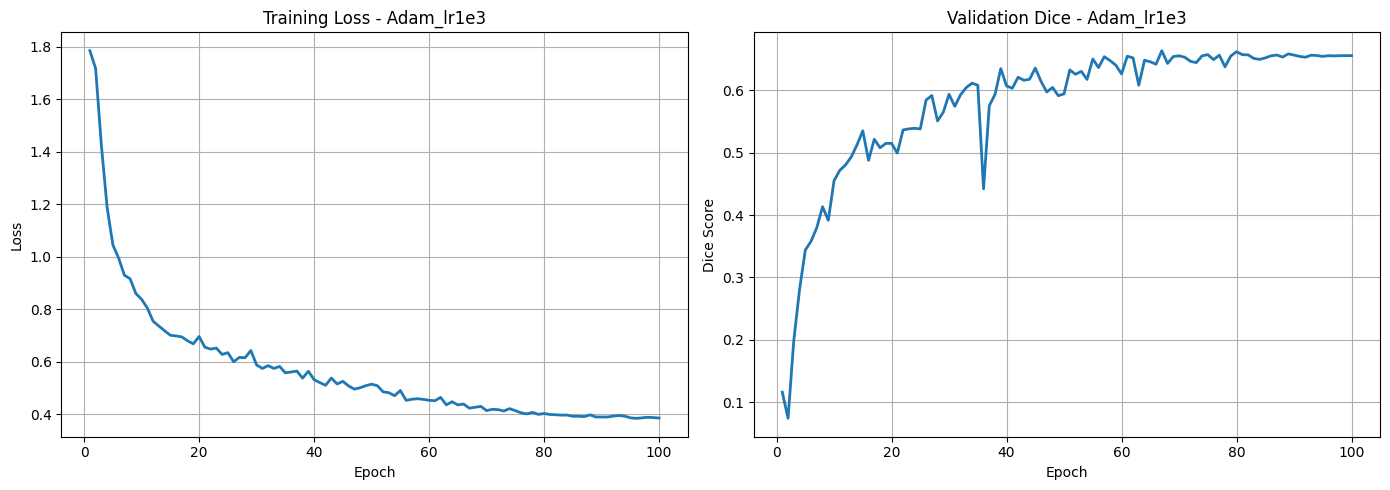

🏃 View run Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/2865c83a38f54743986346c6b1749649
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

Experiment : Adam_lr5e4
Epoch [001/100] | Loss: 1.7739 | Dice: 0.0878 | IoU: 0.0495
Epoch [002/100] | Loss: 1.7007 | Dice: 0.1401 | IoU: 0.0932
Epoch [003/100] | Loss: 1.5292 | Dice: 0.1553 | IoU: 0.1042
Epoch [004/100] | Loss: 1.3779 | Dice: 0.2188 | IoU: 0.1510
Epoch [005/100] | Loss: 1.2426 | Dice: 0.2898 | IoU: 0.2056
Epoch [006/100] | Loss: 1.1211 | Dice: 0.2651 | IoU: 0.1864
Epoch [007/100] | Loss: 1.0244 | Dice: 0.3706 | IoU: 0.2611
Epoch [008/100] | Loss: 0.9542 | Dice: 0.4216 | IoU: 0.2947
Epoch [009/100] | Loss: 0.9378 | Dice: 0.3244 | IoU: 0.2315
Epoch [010/100] | Loss: 0.8503 | Dice: 0.4917 | IoU: 0.3551
Epoch [011/100] | Loss: 0.7996 | Dice: 0.5008 | IoU: 0.3678
Epoch [012/100] | Loss: 0.7845 | Dice: 0.4923 | IoU: 0.3596
Epoch [013/100] | Loss: 0.7598 | Dice: 0.

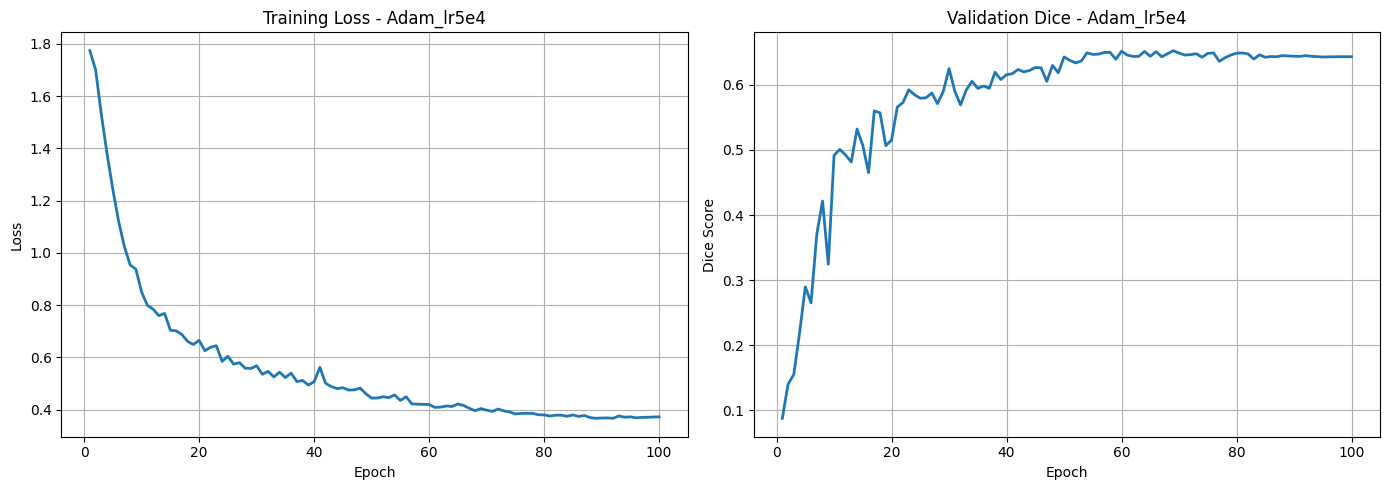

🏃 View run Adam_lr5e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/567b2e0cfc564809a86b65967c63e9c9
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

Experiment : Adam_lr1e4
Epoch [001/100] | Loss: 1.8170 | Dice: 0.0427 | IoU: 0.0239
Epoch [002/100] | Loss: 1.7810 | Dice: 0.0621 | IoU: 0.0365
Epoch [003/100] | Loss: 1.7724 | Dice: 0.0747 | IoU: 0.0450
Epoch [004/100] | Loss: 1.7660 | Dice: 0.0850 | IoU: 0.0528
Epoch [005/100] | Loss: 1.7612 | Dice: 0.1020 | IoU: 0.0641
Epoch [006/100] | Loss: 1.7573 | Dice: 0.1052 | IoU: 0.0669
Epoch [007/100] | Loss: 1.7531 | Dice: 0.1110 | IoU: 0.0705
Epoch [008/100] | Loss: 1.7496 | Dice: 0.1185 | IoU: 0.0754
Epoch [009/100] | Loss: 1.7463 | Dice: 0.1292 | IoU: 0.0831
Epoch [010/100] | Loss: 1.7427 | Dice: 0.1246 | IoU: 0.0796
Epoch [011/100] | Loss: 1.7387 | Dice: 0.1433 | IoU: 0.0918
Epoch [012/100] | Loss: 1.7379 | Dice: 0.1299 | IoU: 0.0837
Epoch [013/100] | Loss: 1.7328 | Dice: 0.

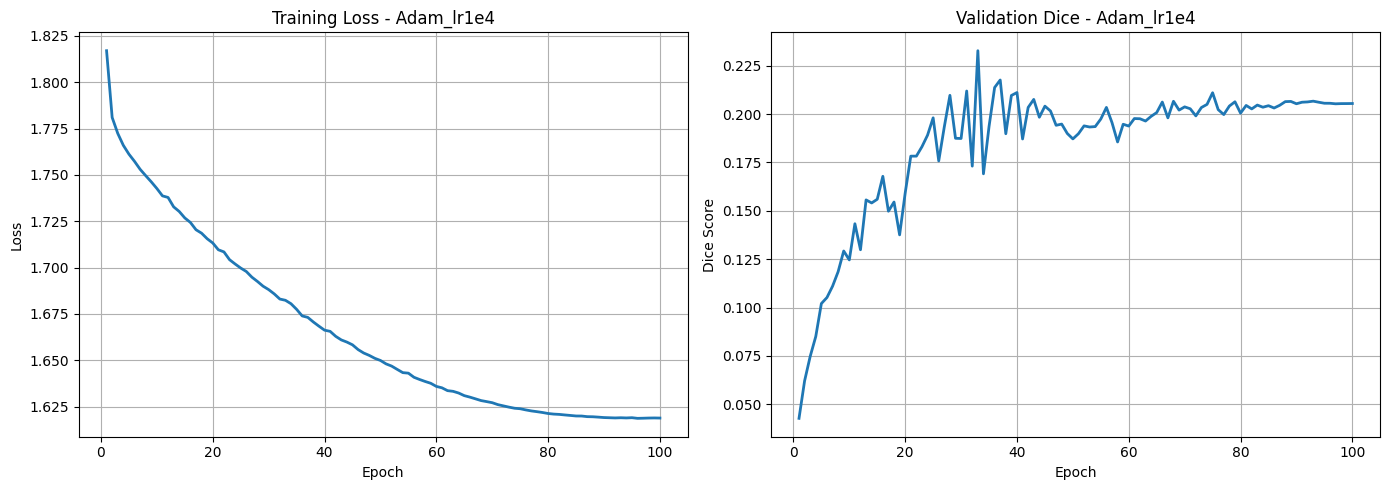

🏃 View run Adam_lr1e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/7348b53b84f24c039478e40af0fc66b5
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

Training completed successfully.


In [17]:
results = []

# Directory to save the best DWI models
DWI_SAVE_DIR = SAVE_DIR / "dwi"
DWI_SAVE_DIR.mkdir(parents=True, exist_ok=True)

for exp in experiments:

    print("\n" + "=" * 60)
    print(f"Experiment : {exp['name']}")
    print("=" * 60)

    # Start MLflow Run
    with mlflow.start_run(run_name=f"DWI-3D_{exp['name']}") as run:

        # Log Run Information
        mlflow.set_tag("architecture", "3D U-Net")
        mlflow.set_tag("modality", "DWI")
        mlflow.set_tag("framework", "PyTorch + MONAI")
        mlflow.set_tag( "experiment_group",  "DWI-3D")
        mlflow.set_tag("modality", "DWI")
        mlflow.set_tag("dimension", "3D")
        mlflow.set_tag("dataset", "ISLES2022")

        # Log Hyperparameters
        mlflow.log_param("model", "3D_UNet")
        mlflow.log_param("architecture", "3D U-Net")
        mlflow.log_param("modality", "DWI")

        mlflow.log_param("optimizer", exp["optimizer"])
        mlflow.log_param("learning_rate", exp["lr"])
        mlflow.log_param("batch_size", BATCH_SIZE)
        mlflow.log_param("epochs", NUM_EPOCHS)
        mlflow.log_param("num_workers", NUM_WORKERS)

        mlflow.log_param("channels", str((16, 32, 64, 128, 256)))

        mlflow.log_param(
            "strides",
            str((2, 2, 2, 2))
        )

        mlflow.log_param("num_res_units", 2)

        # Create 3D U-Net
        model = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=1,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
        ).to(DEVICE)

        # Optimizer
        optimizer = Adam(
            model.parameters(),
            lr=exp["lr"]
        )

        # Learning Rate Scheduler
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=NUM_EPOCHS
        )

        mlflow.log_param(
            "scheduler",
            "CosineAnnealingLR"
        )

        # Best Model Tracking
        best_dice = 0.0
        best_iou = 0.0
        best_epoch = 0

        train_losses = []
        val_dices = []
        val_ious = []

        model_path = DWI_SAVE_DIR / f"best_model_{exp['name']}.pth"

        # Training Loop
        for epoch in range(NUM_EPOCHS):

            # Training
            epoch_loss = train_one_epoch(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                loss_function=loss_function,
                device=DEVICE
            )

            train_losses.append(epoch_loss)

            # Validation
            dice, iou = validate(
                model=model,
                val_loader=val_loader,
                dice_metric=dice_metric,
                iou_metric=iou_metric,
                post_pred=post_pred,
                device=DEVICE
            )

            val_dices.append(dice)
            val_ious.append(iou)

            scheduler.step()

            # Log Metrics Every Epoch
            mlflow.log_metric(
                "train_loss",
                epoch_loss,
                step=epoch + 1
            )

            mlflow.log_metric(
                "val_dice",
                dice,
                step=epoch + 1
            )

            mlflow.log_metric(
                "val_iou",
                iou,
                step=epoch + 1
            )

            # Save Best Model
            if dice > best_dice:

                best_dice = dice
                best_iou = iou
                best_epoch = epoch + 1

                torch.save(
                    model.state_dict(),
                    model_path
                )

            print(
                f"Epoch [{epoch + 1:03d}/{NUM_EPOCHS}] "
                f"| Loss: {epoch_loss:.4f} "
                f"| Dice: {dice:.4f} "
                f"| IoU: {iou:.4f}"
            )

        # Log Best Metrics
        mlflow.log_metric(
            "best_dice",
            best_dice
        )

        mlflow.log_metric(
            "best_iou",
            best_iou
        )

        mlflow.log_metric(
            "best_epoch",
            best_epoch
        )

        # Log Model .pth
        mlflow.log_artifact(
            str(model_path),
            artifact_path="model"
        )

        # Save Training Curves
        curve_path = DWI_SAVE_DIR / f"training_curves_{exp['name']}.png"

        plt.figure(figsize=(14, 5))

        # Training Loss
        plt.subplot(1, 2, 1)

        plt.plot(
            range(1, NUM_EPOCHS + 1),
            train_losses,
            linewidth=2
        )

        plt.title(f"Training Loss - {exp['name']}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)

        # Validation Dice
        plt.subplot(1, 2, 2)

        plt.plot(
            range(1, NUM_EPOCHS + 1),
            val_dices,
            linewidth=2
        )

        plt.title(f"Validation Dice - {exp['name']}")
        plt.xlabel("Epoch")
        plt.ylabel("Dice Score")
        plt.grid(True)

        plt.tight_layout()

        plt.savefig(
            curve_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()

        # Log Training Curves to MLflow
        mlflow.log_artifact(
            str(curve_path),
            artifact_path="plots"
        )

        # Save Results
        results.append({
            "Experiment": exp["name"],
            "Learning Rate": exp["lr"],
            "Best Dice": best_dice,
            "Best IoU": best_iou,
            "Best Epoch": best_epoch,
            "Train Loss": train_losses,
            "Validation Dice": val_dices,
            "Validation IoU": val_ious,
            "Model Path": str(model_path),
            "Run ID": run.info.run_id
        })

print("\nTraining completed successfully.")

### Training Curves (Loss and Dice Score)

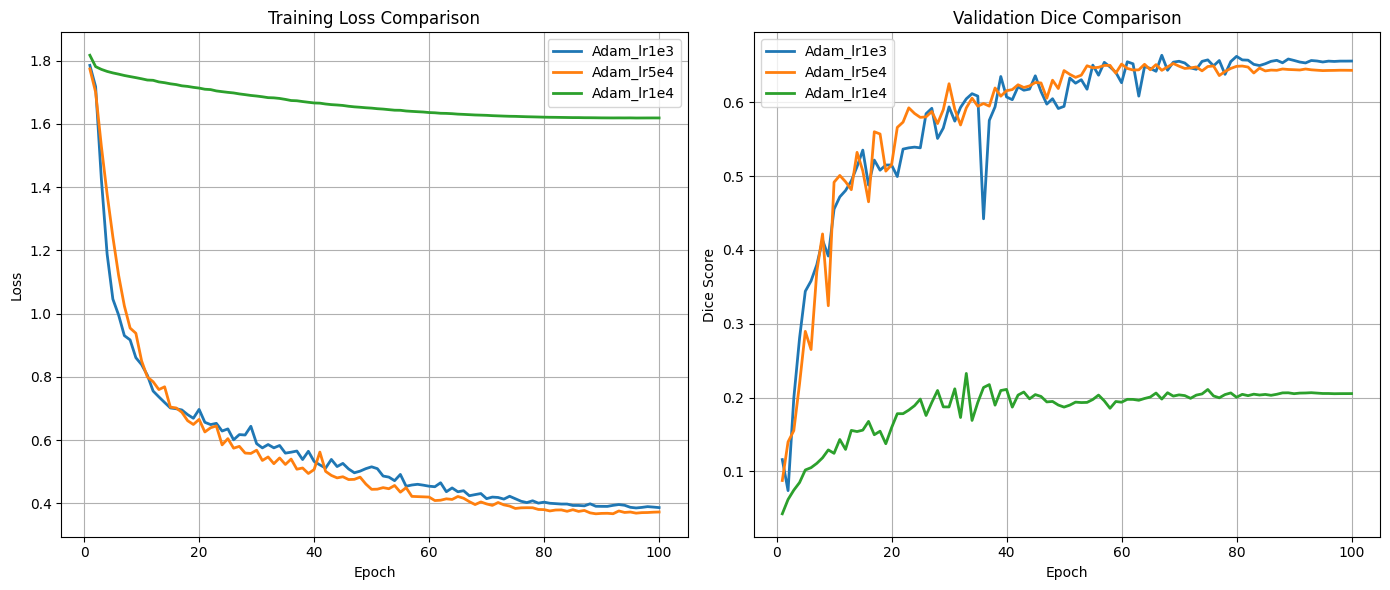

Comparison curves saved to: /kaggle/working/models/dwi/comparison_training_curves.png


In [18]:
plt.figure(figsize=(14, 6))

# Training Loss Comparison
plt.subplot(1, 2, 1)

for result in results:
    plt.plot(
        range(1, len(result["Train Loss"]) + 1),
        result["Train Loss"],
        label=result["Experiment"],
        linewidth=2
    )

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Validation Dice Comparison
plt.subplot(1, 2, 2)

for result in results:
    plt.plot(
        range(1, len(result["Validation Dice"]) + 1),
        result["Validation Dice"],
        label=result["Experiment"],
        linewidth=2
    )

plt.title("Validation Dice Comparison")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save Comparison Figure
comparison_curve_path = DWI_SAVE_DIR / "comparison_training_curves.png"

plt.savefig(
    comparison_curve_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Comparison curves saved to: {comparison_curve_path}")

### Charger le meilleur modèle

In [19]:
import os
import torch
from monai.networks.nets import UNet

best_result = max(results, key=lambda x: x["Best Dice"])

print("=" * 60)
print("Best Training Result")
print("=" * 60)

print(f"Experiment : {best_result['Experiment']}")
print(f"Best Dice  : {best_result['Best Dice']:.4f}")
print(f"Best IoU   : {best_result['Best IoU']:.4f}")
print(f"Best Epoch : {best_result['Best Epoch']}")
print(f"Model Path : {best_result['Model Path']}")
print(f"Best Run ID : {best_result['Run ID']}")

print("=" * 60)

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(DEVICE)


model.load_state_dict(
    torch.load(
        best_result["Model Path"],
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully.")


FINAL_MODEL_PATH = "/kaggle/working/unet3d_dwi_best.pth"

torch.save(
    model.state_dict(),
    FINAL_MODEL_PATH
)

print("=" * 60)
print("Final model saved successfully.")
print(f"Path: {FINAL_MODEL_PATH}")
print("=" * 60)

Best Training Result
Experiment : Adam_lr1e3
Best Dice  : 0.6636
Best IoU   : 0.5181
Best Epoch : 67
Model Path : /kaggle/working/models/dwi/best_model_Adam_lr1e3.pth
Best Run ID : 2865c83a38f54743986346c6b1749649
Best model loaded successfully.
Final model saved successfully.
Path: /kaggle/working/unet3d_dwi_best.pth


### Évaluer sur le jeu de test

In [20]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

dice_metric.reset()
iou_metric.reset()

all_preds = []
all_masks = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        # Forward pass
        outputs = model(images)

        # Binary prediction
        preds = (torch.sigmoid(outputs) > 0.5).float()

        # Update Dice and IoU
        dice_metric(preds, masks)
        iou_metric(preds, masks)

        # Store predictions
        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_masks.extend(
            masks.cpu().numpy().flatten()
        )


# Compute Dice and IoU
dice = dice_metric.aggregate().item()
iou = iou_metric.aggregate().item()


# Compute Precision, Recall and F1-score
all_preds = np.array(all_preds).astype(int)
all_masks = np.array(all_masks).astype(int)

precision = precision_score(
    all_masks,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_masks,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_masks,
    all_preds,
    zero_division=0
)

# Confusion Matrix
cm = confusion_matrix(
    all_masks,
    all_preds
)

# Display Results
results_metrics = pd.DataFrame({

    "Metric": [
        "Dice Score",
        "Mean IoU",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value": [
        dice,
        iou,
        precision,
        recall,
        f1
    ]

})

print("=" * 60)
print("Test Set Evaluation")
print("=" * 60)

display(results_metrics)


# MLflow - Log Test Metrics
with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_metric("test_dice", dice)
    mlflow.log_metric("test_iou", iou)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_metric("test_f1", f1)

Test Set Evaluation


,Metric,Value
0,Dice Score,0.678329
1,Mean IoU,0.551294
2,Precision,0.868706
3,Recall,0.751182
4,F1-score,0.805681


🏃 View run Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/2865c83a38f54743986346c6b1749649
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1


### Bar Chart of Evaluation Metrics

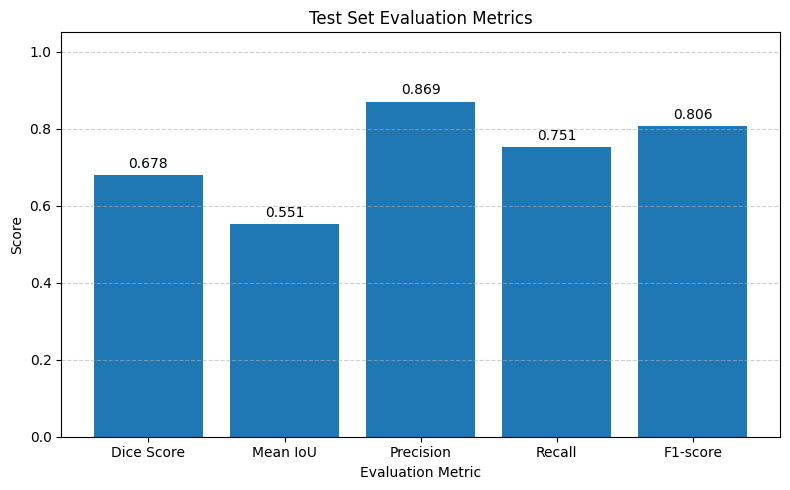

Test metrics plot saved to: /kaggle/working/models/dwi/test_metrics.png
🏃 View run Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/2865c83a38f54743986346c6b1749649
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
Test metrics plot logged to MLflow.


In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    results_metrics["Metric"],
    results_metrics["Value"]
)

plt.title("Test Set Evaluation Metrics")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)

# Display metric values above each bar
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

# ============================================================
# Save Test Metrics Figure
# ============================================================

test_metrics_plot = DWI_SAVE_DIR / "test_metrics.png"

plt.savefig(
    test_metrics_plot,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Test metrics plot saved to: {test_metrics_plot}")

# Log Figure to the Best MLflow Run
with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        str(test_metrics_plot),
        artifact_path="evaluation"
    )

print("Test metrics plot logged to MLflow.")

### Confusion Matrix Visualization

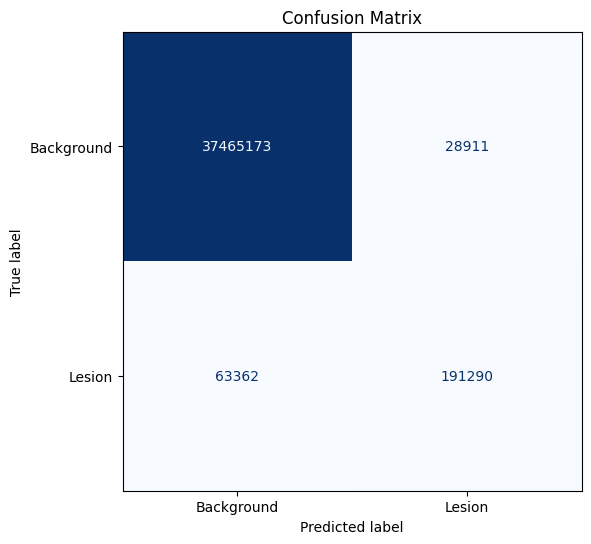

🏃 View run Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/2865c83a38f54743986346c6b1749649
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(all_masks, all_preds)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Background", "Lesion"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title("Confusion Matrix")
ax.grid(False)

plt.tight_layout()

confusion_matrix_path = DWI_SAVE_DIR / "confusion_matrix.png"

plt.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight"
)
plt.show()

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        str(confusion_matrix_path),
        artifact_path="evaluation"
    )

### Random Test Patient Segmentation Visualization

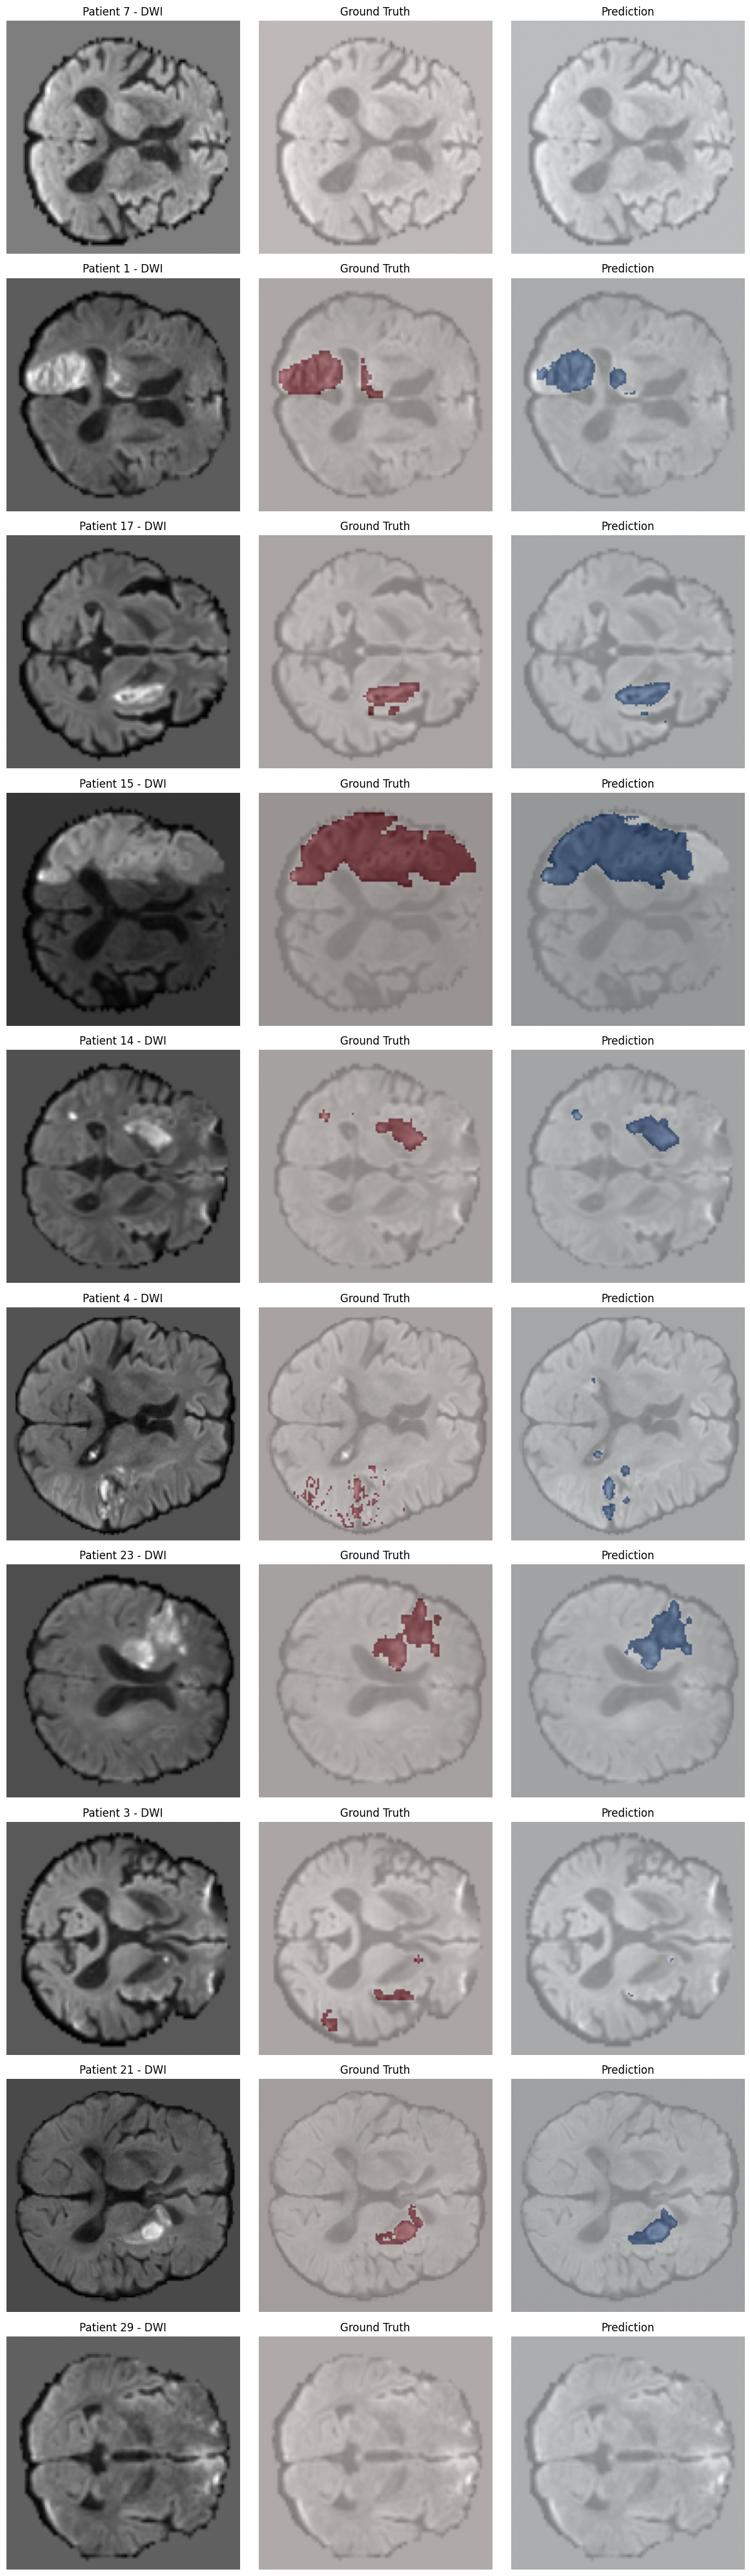

🏃 View run Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/2865c83a38f54743986346c6b1749649
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1


In [23]:
import random
import matplotlib.pyplot as plt

model.eval()

# Select 10 random patients
num_samples = min(10, len(test_dataset))
random_indices = random.sample(range(len(test_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

if num_samples == 1:
    axes = [axes]

with torch.no_grad():

    for row, idx in enumerate(random_indices):

        # Load one patient
        image, mask = test_dataset[idx]

        image = image.unsqueeze(0).to(DEVICE)   # Add batch dimension
        mask = mask.squeeze(0).cpu().numpy()

        # Model prediction
        output = model(image)
        pred = (torch.sigmoid(output) > 0.5).float()

        pred = pred.squeeze().cpu().numpy()
        image = image.squeeze().cpu().numpy()

        # ----------------------------------------------------
        # Display the middle slice
        # ----------------------------------------------------

        slice_idx = image.shape[-1] // 2

        dwi_slice = image[:, :, slice_idx]
        gt_slice = mask[:, :, slice_idx]
        pred_slice = pred[:, :, slice_idx]

        # -------------------- DWI ----------------------------

        axes[row][0].imshow(dwi_slice, cmap="gray")
        axes[row][0].set_title(f"Patient {idx} - DWI")
        axes[row][0].axis("off")

        # ---------------- Ground Truth -----------------------

        axes[row][1].imshow(dwi_slice, cmap="gray")
        axes[row][1].imshow(gt_slice, cmap="Reds", alpha=0.5)
        axes[row][1].set_title("Ground Truth")
        axes[row][1].axis("off")

        # ---------------- Prediction -------------------------

        axes[row][2].imshow(dwi_slice, cmap="gray")
        axes[row][2].imshow(pred_slice, cmap="Blues", alpha=0.5)
        axes[row][2].set_title("Prediction")
        axes[row][2].axis("off")

plt.tight_layout()

prediction_visualization_path = (
    DWI_SAVE_DIR / "prediction_visualization.png"
)

plt.savefig(
    prediction_visualization_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        str(prediction_visualization_path),
        artifact_path="predictions"
    )

In [24]:
import os

for root, dirs, files in os.walk("/kaggle"):

    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

/kaggle/working/unet3d_dwi_best.pth
/kaggle/working/models/dwi/best_model_Adam_lr5e4.pth
/kaggle/working/models/dwi/best_model_Adam_lr1e4.pth
/kaggle/working/models/dwi/best_model_Adam_lr1e3.pth
